link: https://www.kaggle.com/code/hamidrana/what-is-data-augmentation

In [1]:
# Define: 
"""
    Data augmentation is the process of artificially expanding a dataset by 
    creating modified copies of existing data. Its primary goal is to increase 
    the size and diversity of training data without needing to collect new samples, 
    which helps machine learning models generalize better and reduces overfitting.
"""

'\n    Data augmentation is the process of artificially expanding a dataset by \n    creating modified copies of existing data. Its primary goal is to increase \n    the size and diversity of training data without needing to collect new samples, \n    which helps machine learning models generalize better and reduces overfitting.\n'

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/marquis03/cats-and-dogs'):
    print(dirname,'\n',filenames)
    break

/kaggle/input/datasets/marquis03/cats-and-dogs 
 ['val.csv', 'train.csv']


In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import tensorflow as tf
import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2

In [4]:
df = pd.read_csv('/kaggle/input/datasets/marquis03/cats-and-dogs/val.csv')
df.head()

,image:FILE,category
0,val/cat/Persian_13_jpg.rf.dd6ccb81649242fcc8a2...,0
1,val/cat/Birman_137_jpg.rf.dc638a7840b71bfdcc9d...,0
2,val/cat/Siamese_142_jpg.rf.de98806682118bd0281...,0
3,val/cat/Birman_163_jpg.rf.de852821da3d65ebd262...,0
4,val/cat/Bengal_141_jpg.rf.e656908b712d2cb13742...,0


In [5]:
sample = df.sample(1).iloc[0]
sample

image:FILE    val/dog/leonberger_127_jpg.rf.e546fb18911f0ae5...
category                                                      1
Name: 44, dtype: object

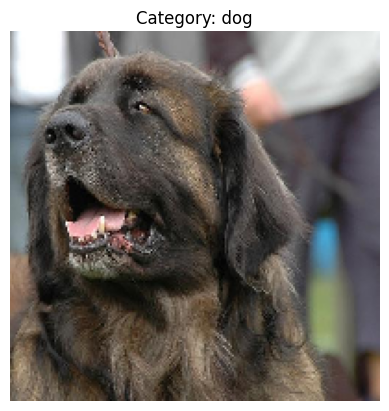

In [6]:
path = "/kaggle/input/datasets/marquis03/cats-and-dogs"
image_path = os.path.join(path, sample["image:FILE"])

img = image.load_img(image_path, target_size=(200, 200))

plt.imshow(img)
plt.title(f'Category: {"dog" if sample["category"] == 1 else "cat"}')
plt.axis("off")
plt.show()

In [7]:
datagen = ImageDataGenerator(
    rotation_range=30,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

In [8]:
img = image.img_to_array(img)
img.shape

(200, 200, 3)

In [9]:
input_batch = img.reshape(1,200,200,3)

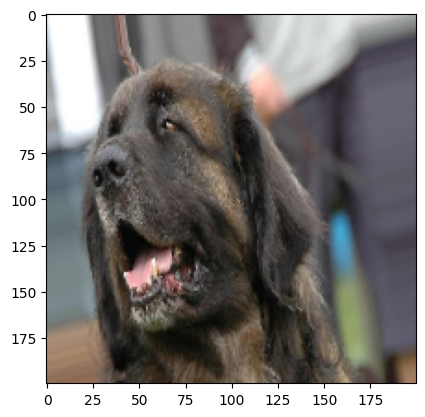

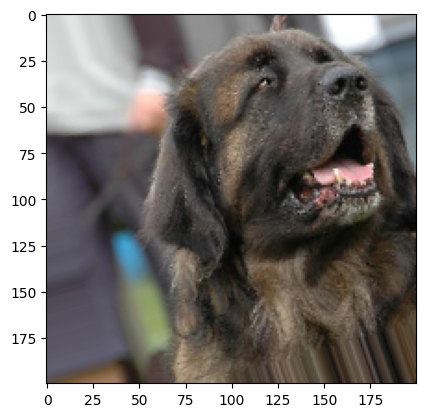

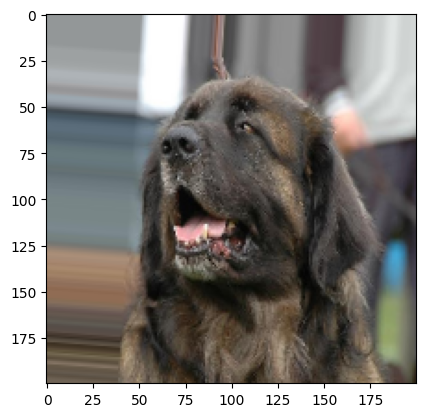

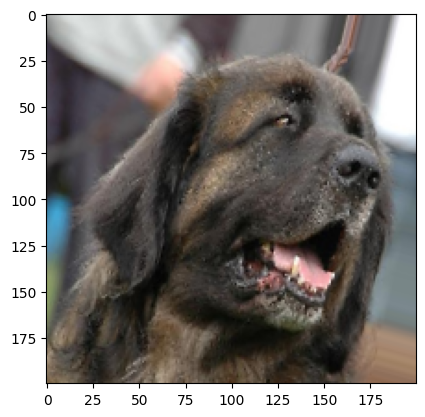

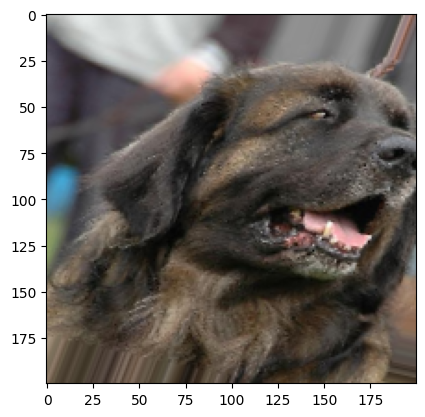

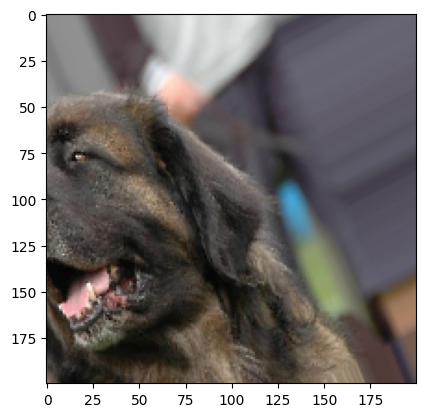

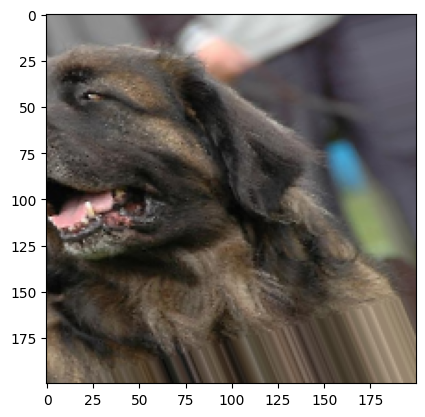

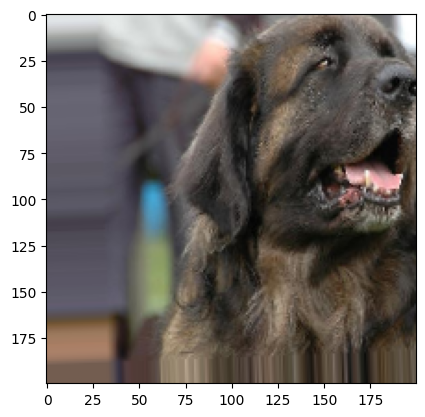

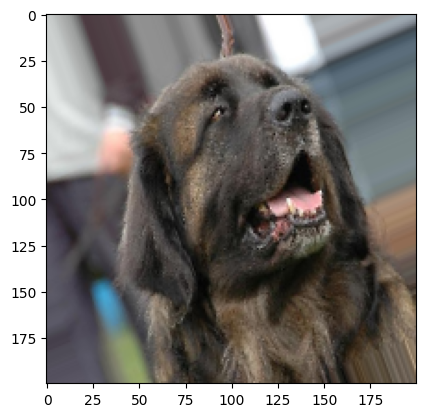

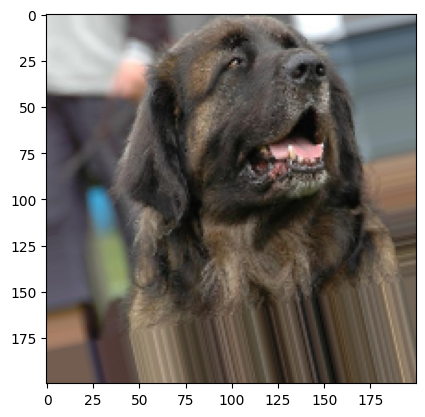

In [10]:
i = 0
for output in datagen.flow(input_batch,batch_size=1):
    i += 1
    plt.imshow(output[0]/ 255)
    plt.show()
    if i==10:
        break